In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [38]:
df = pd.read_csv(r"C:\Users\GR0012AU\Downloads\Social_Network_Ads.csv")

In [39]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
82,15709476,Male,20,49000,0
56,15775562,Female,23,48000,0
64,15605000,Female,59,83000,0
165,15578738,Female,18,86000,0
291,15596522,Male,49,89000,1


In [40]:
df1=df.iloc[:,2:]

In [41]:
df1

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train,x_test,y_train,y_test=train_test_split(df1.iloc[:,:2],df1["Purchased"],test_size=0.3,random_state=0)

In [44]:
y_test

132    0
309    0
341    0
196    0
246    0
      ..
216    0
259    1
49     0
238    0
343    1
Name: Purchased, Length: 120, dtype: int64

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
sc=StandardScaler()

In [47]:
sc.fit(x_train)

StandardScaler()

In [48]:
x_train_sc=sc.transform(x_train)
x_test_sc=sc.transform(x_test)

In [49]:
x_train_sc=pd.DataFrame(x_train_sc,columns=x_train.columns)
x_test_sc=pd.DataFrame(x_test_sc,columns=x_test.columns)

In [50]:
x_train_sc

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


<AxesSubplot:title={'center':'After_Scaling'}, xlabel='Age', ylabel='Density'>

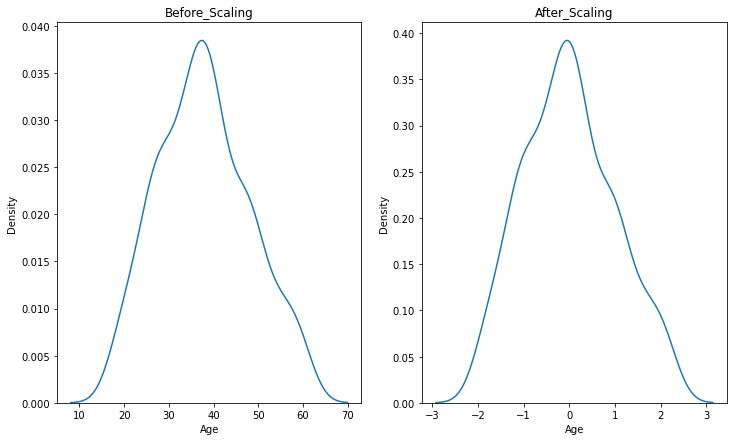

In [73]:
fig, (ax1, ax2)=plt.subplots(ncols=2,figsize=(12,7))
ax1.set_title("Before_Scaling")
sns.kdeplot(x_train["Age"],ax=ax1)
ax2.set_title("After_Scaling")
sns.kdeplot(x_train_sc["Age"],ax=ax2)

<AxesSubplot:title={'center':'After_Scaling'}, xlabel='EstimatedSalary', ylabel='Density'>

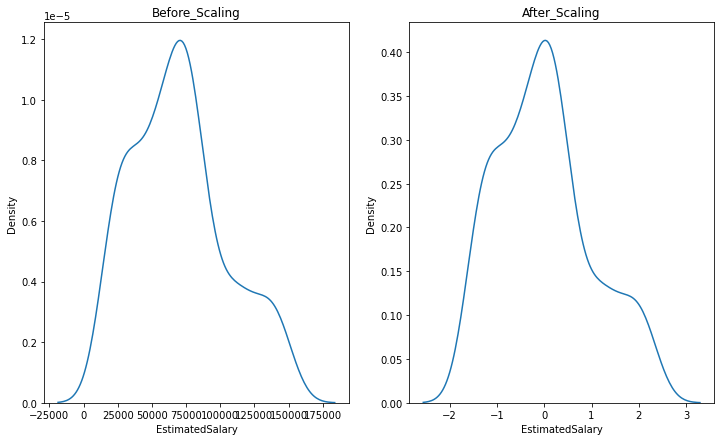

In [74]:
fig, (ax1, ax2)=plt.subplots(ncols=2,figsize=(12,7))
ax1.set_title("Before_Scaling")
sns.kdeplot(x_train["EstimatedSalary"],ax=ax1)
ax2.set_title("After_Scaling")
sns.kdeplot(x_train_sc["EstimatedSalary"],ax=ax2)

Text(0.5, 1.0, 'After_Scaling')

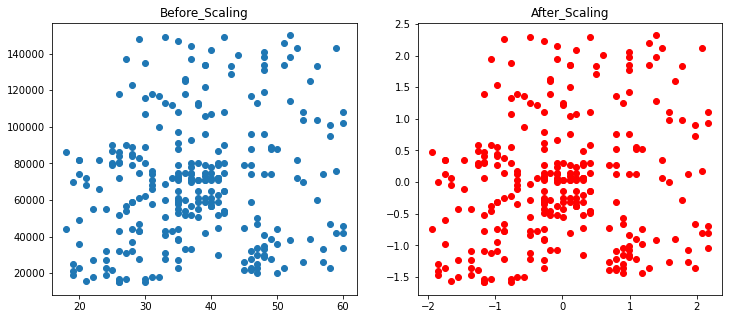

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])
ax1.set_title("Before_Scaling")
ax2.scatter(x_train_sc["Age"],x_train_sc["EstimatedSalary"],color="red")
ax2.set_title("After_Scaling")

Text(0.5, 1.0, 'After_Scaling')

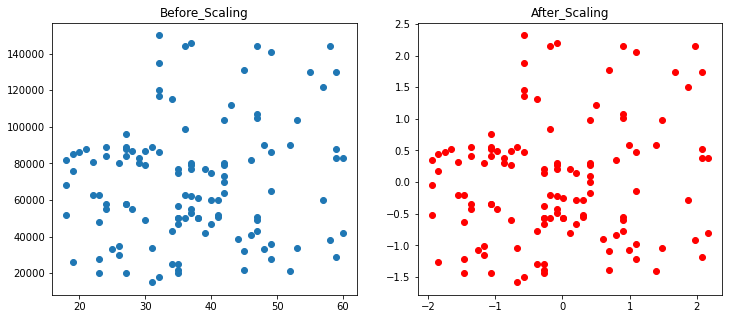

In [60]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(x_test["Age"],x_test["EstimatedSalary"])
ax1.set_title("Before_Scaling")
ax2.scatter(x_test_sc["Age"],x_test_sc["EstimatedSalary"],color="red")
ax2.set_title("After_Scaling")

<AxesSubplot:title={'center':'After Scaling'}, xlabel='Age', ylabel='Density'>

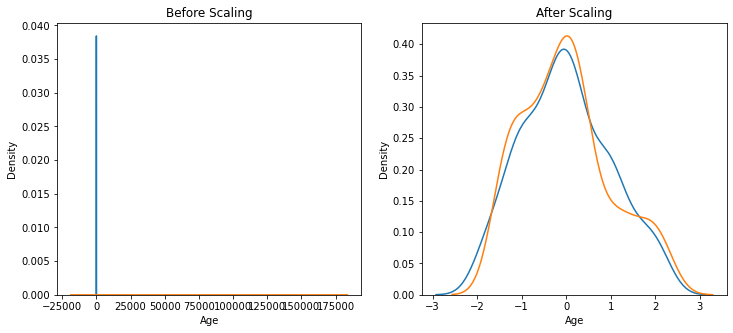

In [70]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.set_title("Before Scaling")
sns.kdeplot(x_train["Age"],ax=ax1)
sns.kdeplot(x_train["EstimatedSalary"],ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(x_train_sc["Age"],ax=ax2)
sns.kdeplot(x_train_sc["EstimatedSalary"],ax=ax2)

In [76]:
from sklearn.linear_model import LogisticRegression

In [83]:
LR=LogisticRegression()
LR1=LogisticRegression()

In [85]:
LR.fit(x_train,y_train)
LR1.fit(x_train_sc,y_train)

LogisticRegression()

In [86]:
predicted=LR.predict(x_test)
predicted_sc=LR1.predict(x_test_sc)

In [87]:
from sklearn.metrics import accuracy_score

In [89]:
print(accuracy_score(y_test,predicted))
print(accuracy_score(y_test,predicted_sc))

0.6583333333333333
0.8666666666666667


In [94]:
df1=df1.append(pd.DataFrame({"Age":[9,90,95],"EstimatedSalary":[9000,250000,150000],"Purchased":[0,1,1]}),ignore_index=True)

C:\Users\GR0012AU\AppData\Local\Temp\ipykernel_83212\105308246.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df1=df1.append(pd.DataFrame({"Age":[9,90,95],"EstimatedSalary":[9000,250000,150000],"Purchased":[0,1,1]}),ignore_index=True)


In [95]:
df1

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
401,90,250000,1
402,95,150000,1
403,9,9000,0
404,90,250000,1


In [96]:
# you can try on this data for your satisfaction